# Turnover in Investments / Trading

**Cryptocurrency Hourly Data & Rank-Demeaned Portfolio Construction**

In this notebook, we connect to Binance using its API to download historical price data for a universe of major cryptocurrencies and construct a simple rank-demeaned, normalized portfolio to illustrate basic cross-sectional trading logic.

In [1]:
# Import and setup
from binance.client import Client as bnb_client
from datetime import datetime
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In the following code, we will define a function that gets the data of our cryptocurrency starting from 2019. We will then store it in a dataframe and derive their percentage change

In [2]:
client = bnb_client()

# Data Retrieval
def get_binance_px(symbol,freq,start_ts = '2019-01-01'):
  """
  We will download historical OHLCV data starting from January 1, 2019.
  The function cleans and converts timestamps from milliseconds to Python datetime objects.
  """
  data = client.get_historical_klines(symbol,freq,start_ts)
  columns = [
    'open_time','open','high','low','close','volume','close_time','quote_volume',
    'num_trades','taker_base_volume','taker_quote_volume','ignore'
  ]
  data = pd.DataFrame(data,columns = columns)
    
  # Convert from POSIX timestamp (number of millisecond since jan 1, 1970)
  data['open_time'] = data['open_time'].map(lambda x: datetime.utcfromtimestamp(x/1000))
  data['close_time'] = data['close_time'].map(lambda x: datetime.utcfromtimestamp(x/1000))
  return data 

univ = ['BTCUSDT','ETHUSDT','ADAUSDT','BNBUSDT','XRPUSDT','DOTUSDT','MATICUSDT']

freq = '1h'
px = {}
for x in univ:
  data = get_binance_px(x,freq)
  px[x] = data.set_index('open_time')['close']

# Data Transformation
px = pd.DataFrame(px).astype(float)
px = px.reindex(pd.date_range(px.index[0],px.index[-1],freq=freq))
ret = px.pct_change()

/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_15451/29641120.py:32: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ret = px.pct_change()


Over here, we will create a simple cross-sectional mean-reversion strategy:

- For each timestamp, we take the negative rolling mean of recent returns (hor = 1 hour).
- We rank assets based on these signals.
- We demean and normalize the portfolio weights such that the sum of absolute weights equals 1:


This results in a market-neutral portfolio that goes long on underperformers and short on outperformers.

---

Refer to this section for more detail in the breakdown 

> 'hor' stands for horizon — here set to 1, meaning we use a 1-period rolling window (in this case, 1 hour).
This horizon can be increased to smooth returns or reduce noise by averaging over multiple periods.

> ret is a DataFrame of returns for multiple assets (columns) over time (rows).

> ret.rolling(hor, min_periods=1).mean() computes the rolling mean return for each asset over the last hor periods.

> Multiplying by -1.0 inverts the signal — so assets with recently high returns become short candidates, while those with recently low returns become long candidates. → This expresses a mean-reversion idea: what went up recently may go down, and vice versa.

>.rank(1) ranks the assets at each timestamp across columns (i.e. across different coins).
The best (most negative) return gets rank 1, and the worst gets the highest rank.
This creates a cross-sectional score for each asset relative to its peers.

> port.mean(1) computes the average rank per time. Subtracting that mean centers the distribution so that the sum of weights = 0 (longs and shorts offset each other). → This enforces market neutrality — no net exposure to market direction.

> Finally, we normalize the portfolio weights so that the sum of absolute weights equals 1. This ensures comparability across time — even if volatility or dispersion of returns changes. It also means that the portfolio always allocates 100% of its "capital" (e.g., 50% long, 50% short).

In [3]:
# standard rank-demean-normalized portfolio
hor = 1
port = (-1.0*ret.rolling(hor,min_periods=1).mean()).rank(1) # Take the negative rolling mean of recent returns, then rank assets based on these signals
port = port.subtract(port.mean(1),0) # We demean the portfolio weights
port = port.divide(port.abs().sum(1),0) # We normalize the portfolio weights such that the sum of absolute weights equals 1
port

,BTCUSDT,ETHUSDT,ADAUSDT,BNBUSDT,XRPUSDT,DOTUSDT,MATICUSDT
2019-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-01 01:00:00,-0.333333,0.000000,0.166667,0.333333,-0.166667,NaN,NaN
2019-01-01 02:00:00,-0.333333,0.000000,-0.166667,0.333333,0.166667,NaN,NaN
2019-01-01 03:00:00,0.166667,0.000000,-0.333333,0.333333,-0.166667,NaN,NaN
2019-01-01 04:00:00,0.333333,-0.166667,0.000000,-0.333333,0.166667,NaN,NaN
...,...,...,...,...,...,...,...
2026-02-10 10:00:00,0.000000,-0.166667,-0.083333,0.166667,0.083333,0.250000,-0.250000
2026-02-10 11:00:00,0.250000,0.083333,0.000000,-0.083333,0.166667,-0.166667,-0.250000
2026-02-10 12:00:00,-0.166667,-0.250000,0.083333,0.166667,-0.083333,0.250000,0.000000
2026-02-10 13:00:00,-0.166667,-0.250000,0.083333,0.166667,0.000000,-0.083333,0.250000


Finally, we compute turnover, which measures how frequently the portfolio positions change

> Any missing weights (NaN) are replaced with 0. This ensures that when assets are added or removed from the universe, their contribution to turnover is treated cleanly — as if there were no position.

> port.shift() moves the entire DataFrame one row down in time, so each row can be compared to the previous portfolio. This represents the portfolio weights at the previous timestamp.

> We compute the difference between the portfolio weights at the present and previous timestamps. This measures the change in portfolio weights for each asset between two consecutive time steps. If a weight stays the same, the difference is 0. If it changes, the difference reflects the amount of reallocation (buying/selling).

> Taking the absolute value converts all changes into positive numbers — since turnover measures how much the portfolio changes, not the direction.

> Summing across all columns (assets) at each timestamp gives the total portfolio turnover per period. For example, if the portfolio sold 0.3 of BTC and bought 0.3 of ETH, the turnover would be 0.3 + 0.3 = 0.6.

In [4]:
# compute turnover
to = (port.fillna(0) - port.shift().fillna(0)).abs().sum(1)
to

2019-01-01 00:00:00    0.000000
2019-01-01 01:00:00    1.000000
2019-01-01 02:00:00    0.666667
2019-01-01 03:00:00    1.000000
2019-01-01 04:00:00    1.666667
                         ...   
2026-02-10 10:00:00    0.666667
2026-02-10 11:00:00    1.333333
2026-02-10 12:00:00    2.000000
2026-02-10 13:00:00    0.666667
2026-02-10 14:00:00    1.500000
Freq: h, Length: 62343, dtype: float64

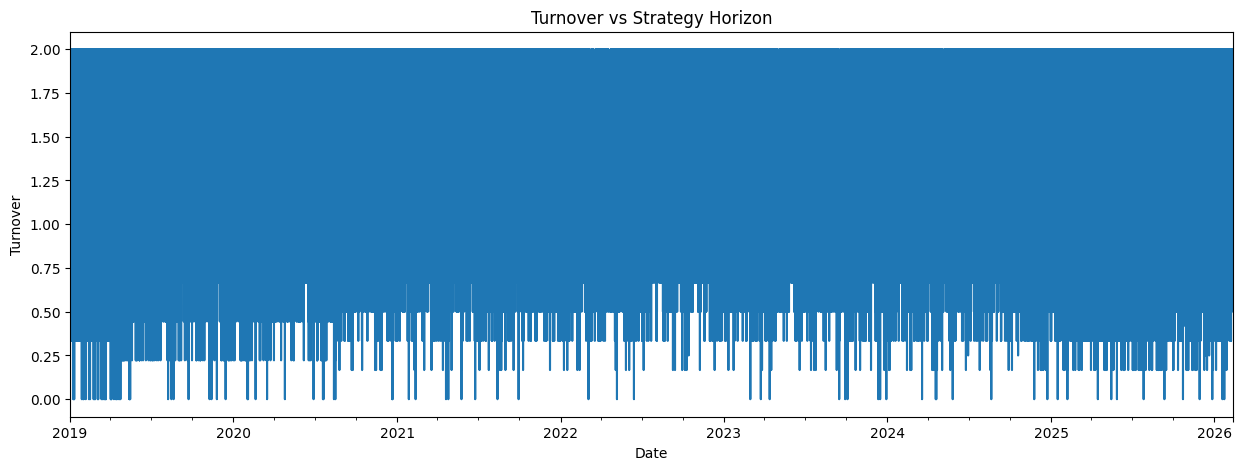

In [5]:
# plot turnover
to.plot()
plt.title("Turnover vs Strategy Horizon")
plt.xlabel("Date")
plt.ylabel("Turnover") 
plt.gcf().set_size_inches(15, 5) # Increase the size of the plot for better visibility
plt.show()

As we can see from the above, the turnover is very frequent across time. The frequency of turnover quantifies how active the strategy is:
- Low turnover → stable portfolio, less trading.
- High turnover → frequent rebalancing, higher transaction costs. 

Let us analyse the average turnover



In [6]:
# average turnover
to.mean()

1.3524704724935706

### We can compute the “Gross of Transaction Costs”. 

This calculation ignores trading frictions such as slippage, bid-ask spreads, and commissions. The term “gross” indicates that this is the raw performance — before subtracting any turnover-related costs. as well as the portfolio Sharpe Ratio. To do so, we will perform the series of steps below:

1. **port.shift()**: The portfolio weights are shifted one period backward in time. This ensures we are using the weights decided at time t-1 to measure returns realized at time t. This avoids lookahead bias as you cannot trade on information you do not yet have.
2. **(port.shift() * ret)**: Here we multiply the previous period’s weights by the current period’s asset returns. This gives the contribution of each asset to the portfolio’s total return at time t.
3. **.sum(1)**: Summing across assets (axis = 1) adds up all contributions to get the portfolio’s overall return at each timestamp.

In [7]:
# gross of tcost returns
gross_ret = (port.shift()*ret).sum(1)

In [8]:
gross_ret.mean() / gross_ret.std() * np.sqrt(24*365)

4.501555071097799

### Net of Realise Returns

This final step adjusts the portfolio’s gross returns to account for transaction costs, yielding the net realized returns.

#### 1. `tcost_bps = 20`
Transaction cost per unit of turnover is assumed to be **20 basis points (bps)**.

- 1 basis point (bp) = 0.01%, so  
- **20 bps = 0.20% = 0.0020** in decimal form.

This includes both **commissions** (e.g., exchange fees) and **slippage** (price impact when trading).

#### 2. `to * tcost_bps * 1e-4`

**Recall:**

- `to` is **turnover**, the total fraction of the portfolio traded between time steps.
- `tcost_bps * 1e-4` converts basis points to a **decimal cost per unit turnover**.

So, for each timestamp:

$$
\text{Transaction Cost}_t = \text{Turnover}_t \times \text{Cost per Unit Turnover}
$$

**For example:**

If turnover = 0.6 (i.e., 60% of the portfolio was traded), and cost = 20 bps = 0.0020, then:

$$
\text{Transaction Cost}_t = 0.6 \times 0.0020 = 0.0012 = 0.12\%
$$

#### 3. `gross_ret.subtract(..., fill_value=0)`

Subtracts transaction costs from gross returns to compute **net returns**:

$$
\text{Net Return}_t = \text{Gross Return}_t - \text{Transaction Cost}_t
$$

The `fill_value=0` ensures missing values (NaNs) are treated as **0** during subtraction.

#### Mathematical Form

$$
\text{Net Return}_t = \sum_i w_{t-1,i} r_{t,i} - \text{Turnover}_t \times \text{Cost per Unit Turnover}
$$

---

#### Interpretation

- `gross_ret` → what your portfolio would earn in a **frictionless world**.  
- `to * tcost_bps * 1e-4` → represents the **drag from trading activity**.  
- `net_ret` → what you **actually keep** after paying for trading.

In [9]:
# net of tcost returns
tcost_bps = 20 # (comissions + slip)
net_ret = gross_ret.subtract(to*tcost_bps*1e-4,fill_value=0)

In [10]:
net_ret.mean() / net_ret.std() * np.sqrt(24*365)

-68.87113202003161